# France 2017-2022 extended migration analysis

This notebook extends the original France 2018 pilot to all available FRA facts files from 2017 through 2022.

It adds two hypothesis layers:

1. **Concreteness / abstractness**: score each migration context window and compare WEOG versus non-WEOG mentioned countries.
2. **Institutional cohorts and policy diffusion**: classify migrant cohorts and policy measures, then build a France -> mentioned-country network.


In [1]:
import sys
from pathlib import Path

# Explanation: Make the src package importable from the notebook directory.
sys.path.insert(0, str(Path.cwd().parent))

import polars as pl
from IPython.display import Image, display

from src import concreteness, diffusion, filters, geo, load, typology, visualize
from src.config import PROCESSED_DIR, SOURCE_COUNTRY, SOURCE_YEARS


## Method notes

**Migration filtering.** We keep rows where `debate_topic == "immig"` and also rows where the previous/current/next sentence window contains migration keywords: `refugee`, `migrant`, `immigrant`, `asylum`, `migration`, or `immigration`.

**Concreteness.** The code supports a Brysbaert-style 1-5 concreteness lexicon if one is supplied. If no lexicon is loaded, the notebook uses a transparent fallback heuristic: named entities are scored as maximally concrete (`5.0`), physical/institutional markers are concrete, and abstract value/principle words are abstract. The output column `concreteness_method` records which method was used.

**Country recognition.** The parquet already contains NER output in `entity_content`; we normalize country-name variants and then map canonical names to ISO3 and WEOG/non-WEOG groups.

**Cohorts and policy measures.** The current implementation uses auditable keyword rules that produce the same columns a later zero-shot classifier would produce: `migrant_cohort` and `policy_measure`. This keeps the pipeline runnable without downloading transformer models.


In [2]:
# Explanation: Load all available France facts files for 2017-2022 lazily.
lf = load.load_facts_multi_year_lazy(SOURCE_YEARS, country=SOURCE_COUNTRY)
load.inspect_schema(lf)

# Explanation: Quick row-count check by source year before filtering.
lf.group_by("source_year").agg(pl.len().alias("n_rows")).sort("source_year").collect()


=== Schema ===
  entity_word_id: String
  speech_id: String
  paragraph_id: String
  sentence_id: String
  sentence_content_current: String
  sentence_content_previous: String
  sentence_content_next: String
  sentence_sentiment_value: Float32
  sentence_sentiment_ana: String
  total_tokens_in_speech: Int32
  total_tokens_in_session: Int32
  entity_category: String
  entity_content: String
  country: String
  session_date: Date
  debate_topic: String
  speaker_id: String
  speaker_ana: String
  source_year: Int32

Total rows: 1,304,983


source_year,n_rows
i32,u32
2017,132751
2018,321404
2019,287260
2020,241858
2021,268326
2022,53384


In [3]:
# Explanation: Build multi-year migration mentions with country/entity normalization.
mentions = filters.build_migration_mentions(
    lf,
    use_topic=True,
    use_keywords=True,
)
print(f"Retained migration mentions, {SOURCE_YEARS[0]}-{SOURCE_YEARS[-1]}: {mentions.height:,}")

# Explanation: Add the analytical layers used by the hypotheses.
annotated = (
    mentions
    .pipe(typology.apply_typology)
    .pipe(geo.add_country_metadata)
    .pipe(concreteness.add_concreteness_scores)
    .pipe(diffusion.add_diffusion_classifications)
)

out_path = PROCESSED_DIR / f"{SOURCE_COUNTRY}_{SOURCE_YEARS[0]}_{SOURCE_YEARS[-1]}_migration_mentions_extended.parquet"
annotated.write_parquet(out_path)
print(f"Saved {annotated.height:,} rows to {out_path}")
annotated.head(10)


Retained migration mentions, 2017-2022: 4,256


Saved 4,256 rows to /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/FRA_2017_2022_migration_mentions_extended.parquet


source_year,sentence_id,speech_id,session_date,speaker_id,speaker_ana,entity_content,geo_class,region_group,context_window,sentence_content_current,sentence_sentiment_value,sentence_sentiment_ana,debate_topic,country,ref_type,sentiment_level,sentiment_readable,sentiment_polarity,target_iso3,weog_group,concreteness_score,concreteness_method,migrant_cohort,policy_measure
i32,str,str,date,str,str,str,str,str,str,str,f32,str,str,str,str,str,str,str,str,str,f64,str,str,str
2017,"""ParlaMint-FR_2017-07-03-C1001.…","""ParlaMint-FR_2017-07-03-C1001.…",2017-07-03,"""PA335758""","""regular""","""European Union""","""european_union""","""european_union""","""We welcome the revival of the …","""We are convinced that only the…",4.642,"""senti:pospos""","""gover""","""FRA""","""situation""","""senti:pospos""","""strong pos""","""positive""",null,"""european_union""",3.286,"""transparent_fallback_heuristic""","""general_migration""","""general_policy"""
2017,"""ParlaMint-FR_2017-07-03-O1001.…","""ParlaMint-FR_2017-07-03-O1001.…",2017-07-03,"""PA335758""","""regular""","""European Union""","""european_union""","""european_union""","""We welcome the revival of the …","""We are convinced that only the…",4.642,"""senti:pospos""","""gover""","""FRA""","""situation""","""senti:pospos""","""strong pos""","""positive""",null,"""european_union""",3.286,"""transparent_fallback_heuristic""","""general_migration""","""general_policy"""
2017,"""ParlaMint-FR_2017-07-04-E1001.…","""ParlaMint-FR_2017-07-04-E1001.…",2017-07-04,"""PA345619""","""regular""","""Mayotte""","""french_overseas""","""french_overseas""","""Courage is also to face the mi…","""The pressure exerted at the bo…",0.179,"""senti:negneg""","""defen""","""FRA""","""situation""","""senti:negneg""","""strong neg""","""negative""",null,"""french_overseas""",3.327,"""transparent_fallback_heuristic""","""general_migration""","""national_security"""
2017,"""ParlaMint-FR_2017-07-04-E1001.…","""ParlaMint-FR_2017-07-04-E1001.…",2017-07-04,"""PA345619""","""regular""","""French Guiana""","""french_overseas""","""french_overseas""","""Courage is also to face the mi…","""The pressure exerted at the bo…",0.179,"""senti:negneg""","""defen""","""FRA""","""situation""","""senti:negneg""","""strong neg""","""negative""",null,"""french_overseas""",3.387,"""transparent_fallback_heuristic""","""general_migration""","""national_security"""
2017,"""ParlaMint-FR_2017-07-06-E1004.…","""ParlaMint-FR_2017-07-06-E1004.…",2017-07-06,"""PA267527""","""regular""","""Mont Blanc""","""foreign""","""non_european_country""","""I 'm not sure it includes bord…","""You will therefore allow me to…",3.733,"""senti:mixpos""","""immig""","""FRA""","""mixed""","""senti:mixpos""","""mixed pos""","""positive""",null,"""unknown""",3.256,"""transparent_fallback_heuristic""","""general_migration""","""national_security"""
2017,"""ParlaMint-FR_2017-07-12-E1009.…","""ParlaMint-FR_2017-07-12-E1009.…",2017-07-12,"""PA720362""","""regular""","""Place Stalingrad""","""foreign""","""non_european_country""","""I put it on behalf of my colle…","""Minister of State , in Novembe…",0.77,"""senti:mixneg""","""immig""","""FRA""","""mixed""","""senti:mixneg""","""mixed neg""","""negative""",null,"""unknown""",3.297,"""transparent_fallback_heuristic""","""general_migration""","""general_policy"""
2017,"""ParlaMint-FR_2017-07-12-E1009.…","""ParlaMint-FR_2017-07-12-E1009.…",2017-07-12,"""PA720362""","""regular""","""Ney Boulevard""","""foreign""","""non_european_country""","""Minister of State , in Novembe…","""Seven months later , on July 7…",0.49,"""senti:negneg""","""immig""","""FRA""","""mixed""","""senti:negneg""","""strong neg""","""negative""",null,"""unknown""",3.306,"""transparent_fallback_heuristic""","""general_migration""","""general_policy"""
2017,"""ParlaMint-FR_2017-07-12-E1009.…","""ParlaMint-FR_2017-07-12-E1009.…",2017-07-12,"""PA720362""","""regular""","""Blida""","""foreign""","""non_european_country""","""These relocations were necessa

In [4]:
# Explanation: Basic yearly coverage after filtering.
yearly_counts = (
    annotated
    .group_by("source_year")
    .agg(pl.len().alias("n_mentions"))
    .sort("source_year")
)
yearly_counts


source_year,n_mentions
i32,u32
2017,468
2018,1728
2019,874
2020,406
2021,544
2022,236


In [5]:
# Explanation: Direct table for the abstraction/concreteness hypothesis.
regional_concreteness = concreteness.regional_concreteness_summary(annotated)
regional_concreteness


weog_group,n_mentions,mean_concreteness,median_concreteness,sd_concreteness
str,u32,f64,f64,f64
"""non_weog""",1070,3.233,3.229,0.057
"""weog""",1014,3.243,3.234,0.072
"""french_overseas""",783,3.25,3.243,0.08
"""unknown""",839,3.259,3.251,0.075
"""european_union""",550,3.296,3.286,0.091


In [6]:
# Explanation: Top mentioned entities across the whole 2017-2022 window.
top_entities = (
    annotated
    .group_by(["entity_content", "geo_class", "region_group", "weog_group", "target_iso3"])
    .agg([
        pl.len().alias("n_mentions"),
        pl.col("concreteness_score").mean().round(3).alias("mean_concreteness"),
    ])
    .sort("n_mentions", descending=True)
    .head(30)
)
top_entities


entity_content,geo_class,region_group,weog_group,target_iso3,n_mentions,mean_concreteness
str,str,str,str,str,u32,f64
"""Mayotte""","""french_overseas""","""french_overseas""","""french_overseas""",null,610,3.262
"""European Union""","""european_union""","""european_union""","""european_union""",null,550,3.296
"""United Kingdom""","""foreign""","""european_country""","""weog""","""GBR""",208,3.26
"""Germany""","""foreign""","""european_country""","""weog""","""DEU""",160,3.229
"""Comoros""","""foreign""","""non_european_country""","""non_weog""","""COM""",152,3.23
…,…,…,…,…,…,…
"""Belarus""","""foreign""","""european_country""","""non_weog""","""BLR""",21,3.244
"""Lebanon""","""foreign""","""non_european_country""","""non_weog""","""LBN""",20,3.251
"""Sweden""","""foreign""","""european_country""","""weog""","""SWE""",19,3.229


In [7]:
# Explanation: Build diffusion edges with migrant cohort and policy measure attributes.
edges = diffusion.build_diffusion_edges(annotated, source_country=SOURCE_COUNTRY)
network_paths = diffusion.save_diffusion_outputs(
    edges,
    processed_dir=PROCESSED_DIR,
    prefix=f"{SOURCE_COUNTRY}_{SOURCE_YEARS[0]}_{SOURCE_YEARS[-1]}",
)
print(network_paths)
edges.head(20)


{'edges_csv': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/FRA_2017_2022_diffusion_edges.csv'), 'target_summary_csv': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/FRA_2017_2022_diffusion_target_summary.csv'), 'graphml': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/FRA_2017_2022_diffusion_network.graphml')}


source_country,target_entity,target_iso3,geo_class,region_group,weog_group,source_year,migrant_cohort,policy_measure,ref_type,weight,n_sentences
str,str,str,str,str,str,i32,str,str,str,u32,u32
"""FRA""","""Mayotte""",null,"""french_overseas""","""french_overseas""","""french_overseas""",2019,"""general_migration""","""general_policy""","""policy""",70,67
"""FRA""","""Mayotte""",null,"""french_overseas""","""french_overseas""","""french_overseas""",2018,"""general_migration""","""general_policy""","""policy""",49,47
"""FRA""","""Mayotte""",null,"""french_overseas""","""french_overseas""","""french_overseas""",2018,"""general_migration""","""general_policy""","""situation""",44,44
"""FRA""","""Mayotte""",null,"""french_overseas""","""french_overseas""","""french_overseas""",2019,"""general_migration""","""general_policy""","""situation""",42,41
"""FRA""","""European Union""",null,"""european_union""","""european_union""","""european_union""",2018,"""general_migration""","""general_policy""","""policy""",33,31
…,…,…,…,…,…,…,…,…,…,…,…
"""FRA""","""United Kingdom""","""GBR""","""foreign""","""european_country""","""weog""",2018,"""general_migration""","""general_policy""","""policy""",14,14
"""FRA""","""European Union""",null,"""european_union""","""european_union""","""european_union""",2020,"""general_migration""","""returns_deportation""","""policy""",13,13
"""FRA""","""Italy""","""ITA""","""foreign""","""european_country""","""weog""",2018,"""general_migration""","""general_policy""","""policy""",13,13


In [8]:
# Explanation: Save the extended Altair visualizations as HTML, PNG, and Vega-Lite JSON.
figure_paths = visualize.save_extended_figures(
    annotated,
    edges,
    processed_dir=PROCESSED_DIR,
)
figure_paths


{'concreteness_density_by_weog': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/concreteness_density_by_weog.png'),
 'concreteness_by_year_region': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/concreteness_by_year_region.png'),
 'diffusion_top_targets': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/diffusion_top_targets.png'),
 'cohort_policy_heatmap': PosixPath('/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/cohort_policy_heatmap.png')}

concreteness_density_by_weog: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/concreteness_density_by_weog.png


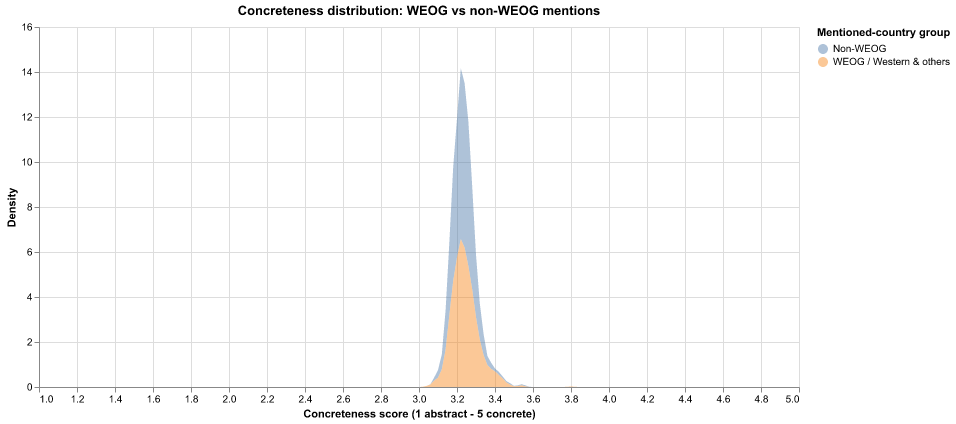

concreteness_by_year_region: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/concreteness_by_year_region.png


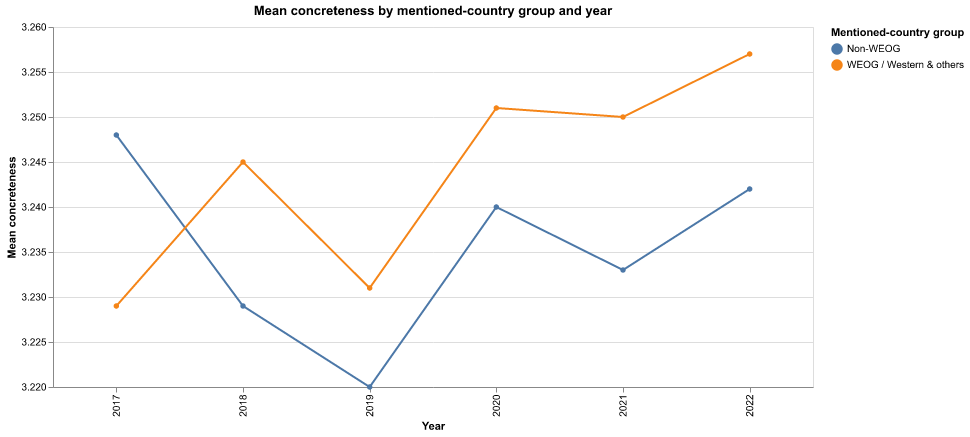

diffusion_top_targets: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/diffusion_top_targets.png


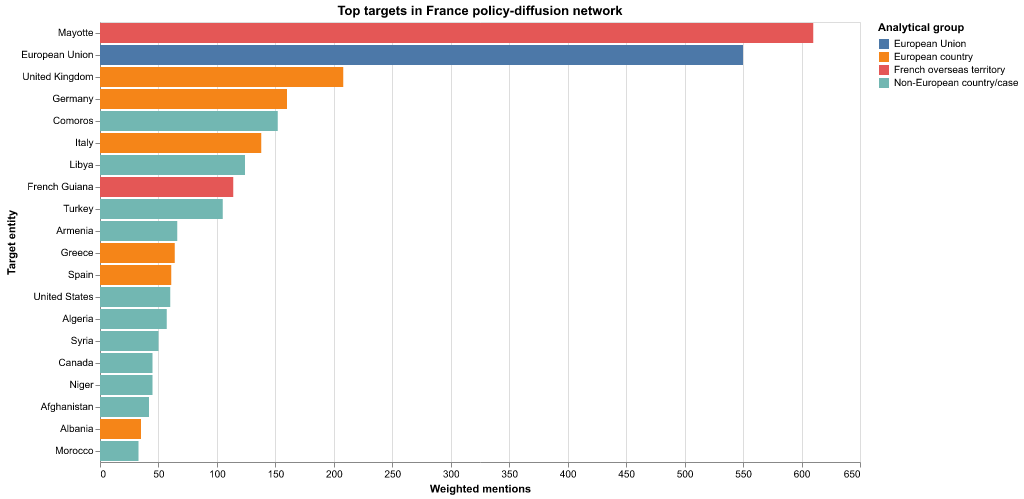

cohort_policy_heatmap: /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/cohort_policy_heatmap.png


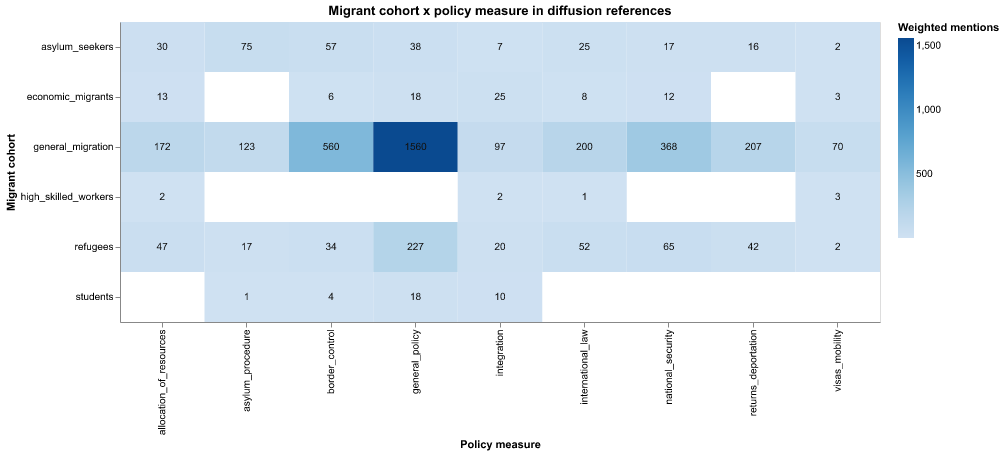


Interactive HTML files:
/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/cohort_policy_heatmap.html
/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/concreteness_by_year_region.html
/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/concreteness_density_by_weog.html
/Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/figures_altair_extended/diffusion_top_targets.html


In [9]:
# Explanation: Display saved static PNGs inline and print all paths.
for output_name, output_path in figure_paths.items():
    print(f"{output_name}: {output_path}")
    if str(output_path).endswith(".png"):
        display(Image(filename=str(output_path)))

print("\nInteractive HTML files:")
for html_path in sorted((PROCESSED_DIR / "figures_altair_extended").glob("*.html")):
    print(html_path)
